Loaded 'csi' with shape (13115, 490) and dtype complex128
PCA Info:
  Input shape: (13115, 490)
  Using PCs 2 to 9
  Variance explained: 45.66%
  Output shape: (13115, 8)


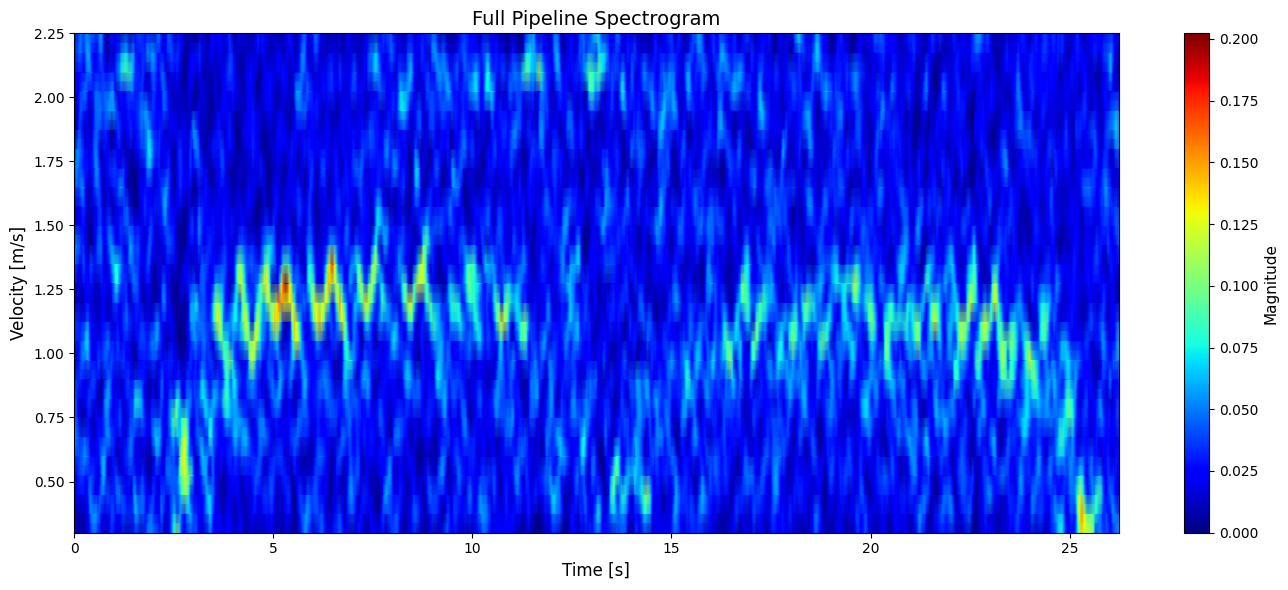

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.special import hermite, factorial
import scipy.io as sio
from scipy.signal import stft, get_window
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample_poly, butter, filtfilt, find_peaks
import os

def compute_STFT(signal_in, fs, T_win=0.4):
    """
    Computes STFT for each column of CSI magnitude.

    Parameters:
        signal_in : np.ndarray
            2D CSI data (time x subcarriers) or 1D array (single time series).
        fs : float
            Sampling rate (Hz)
        T_win : float
            Window length (seconds)
        T_overlap : float
            Overlap length (seconds)
    Returns:
        freq : list of arrays
            Frequency arrays for each column
        time : list of arrays
            Time arrays for each column
        mag : list of 2D arrays
            STFT magnitude arrays for each column
    """
    # Is input single time series
    is_single_time_series = (signal_in.ndim == 1) or (signal_in.ndim == 2 and signal_in.shape[1] == 1)

    # Ensure signal_in is always consistent size
    if signal_in.ndim == 1:
        signal_in_processed = signal_in.reshape(-1, 1)
    elif signal_in.ndim == 2 and signal_in.shape[0] == 1 and signal_in.shape[1] > 1:
        # If it's a row vector (1, N), transpose to (N, 1) to treat as N_samples, 1_component
        signal_in_processed = signal_in.T
    else:
        signal_in_processed = signal_in

    T_overlap = T_win * 0.99

    nperseg = int(T_win * fs)
    noverlap = int(T_overlap * fs)

    # Initialize as empty lists
    freq = []
    time = []
    mag = []

    for i in range(signal_in_processed.shape[1]):
        # Compute STFT for this subcarrier/component
        f, t, Zxx = signal.stft(
            signal_in_processed[:, i],
            fs=fs,
            window='hann',
            nperseg=nperseg,
            noverlap=noverlap,
            detrend=False,
            return_onesided=True
        )
        # Append to lists
        freq.append(f)
        time.append(t)
        mag.append(np.abs(Zxx))

    if is_single_time_series:
        return np.array(freq[0]), np.array(time[0]), np.array(mag[0])
    else:
        return np.array(freq[0]), np.array(time[0]), np.array(mag)


def plot_spectrogram(f, t, S,
                     v_min=0.3,
                     v_max=2.25,
                     title="Spectrogram",
                     cmap='jet',
                     dB=True,
                     figsize=(14,6)):

    """
    Plots a spectrogram given frequency, time, and magnitude values.

    Parameters:
        f : 1D array
            Frequencies (Hz)
        t : 1D array
            Time stamps (s)
        S : 2D array
            Magnitude or power matrix with shape (len(f), len(t))
        title : str
            Plot title
        f_max : float
            Maximum frequency to show (Hz)
        cmap : str
            Matplotlib colormap
        dB : bool
            If True, convert magnitude to dB
        vmin_percentile : float
            Lower percentile for dynamic range scaling
        vmax_percentile : float
            Upper percentile for dynamic range scaling
        figsize : tuple
            Figure size
    """

    # convert from frequency to velocity
    lambda_val = 0.06  # meters for 5 GHz WiFi
    v = f * lambda_val / 2

    S_plot = S

    # Plot
    plt.figure(figsize=figsize)
    plt.pcolormesh(t, v, S_plot,
                   shading='gouraud',
                   cmap=cmap)

    plt.title(title, fontsize=14)
    plt.xlabel("Time [s]", fontsize=12)
    plt.ylabel("Velocity [m/s]", fontsize=12)

    # Limit frequency axis
    if v_max is not None:
        plt.ylim([v_min, v_max])
        # plt.xlim([0, 10])

    cbar = plt.colorbar()
    cbar.set_label("Magnitude", fontsize=11)

    plt.tight_layout()
    plt.show()

def compute_pca_components(signal_clean, n_components=80, skip_first=1, whiten=False):
    """
    Compute PCA on CSI data and project onto principal components

    Parameters:
    -----------
    signal_clean : ndarray
        Preprocessed CSI data, shape (T, N) where:
        - T = number of time samples
        - N = number of subcarriers/streams
    n_components : int
        Number of principal components to extract (default: 80)
    skip_first : int
        Number of first PCs to skip (default: 1, skips PC1 which contains noise)
    Returns:
    --------
    X_proj : ndarray
        Projected data onto selected PCs, shape (T, n_components)
        If whiten=True, this is whitened; otherwise raw projections
    eigvals : ndarray
        All eigenvalues sorted descending, shape (N,)
    eigvecs : ndarray
        All eigenvectors sorted by eigenvalue, shape (N, N)
    """

    # Covariance matrix
    T, N = signal_clean.shape
    Cov = (signal_clean.T @ signal_clean) / (T - 1)

    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eig(Cov)

    # Sort eigenvalues (descending) and reorder eigenvectors
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]  # columns are eigenvectors

    # Select PCs from skip_first to (skip_first + n_components)
    V_k = eigvecs[:, skip_first:skip_first + n_components]  # shape (N, n_components)

    # Project data onto selected PCs
    X_proj = signal_clean @ V_k  # shape (T, n_components)

    # Print diagnostic info
    total_variance = np.sum(eigvals)
    selected_variance = np.sum(eigvals[skip_first:skip_first + n_components])
    print(f"PCA Info:")
    print(f"  Input shape: {signal_clean.shape}")
    print(f"  Using PCs {skip_first+1} to {skip_first+n_components}")
    print(f"  Variance explained: {selected_variance/total_variance*100:.2f}%")
    print(f"  Output shape: {X_proj.shape}")

    return X_proj, eigvals, eigvecs

def adaptive_noise_floor_per_pc(S, f_band, f1, f2):
    """
    Adaptive noise floor removal for spectrograms

    Parameters:
    -----------
    S : ndarray
        Spectrogram(s) with shape:
        - (n_freqs, n_times) for single spectrogram, OR
        - (n_pcs, n_freqs, n_times) for multiple PC spectrograms
    f_band : ndarray
        Frequency values, shape (n_freqs,)
    noise_threshold : float
        Frequency (Hz) above which to estimate noise floor

    Returns:
    --------
    S_clean : ndarray
        Cleaned spectrogram, same shape as input S
    """
    # Handle both 2D and 3D inputs
    if S.ndim == 2:
        # Single spectrogram: (n_freqs, n_times)
        # Add dummy dimension to treat as single PC
        S = S[np.newaxis, :, :]
        squeeze_output = True
    elif S.ndim == 3:
        # Multiple PC spectrograms: (n_pcs, n_freqs, n_times)
        squeeze_output = False
    else:
        raise ValueError(f"S must be 2D or 3D, got shape {S.shape}")

    n_pcs, n_freqs, n_times = S.shape
    S_clean = np.zeros_like(S)

    # Select frequencies in the noise band f1 → f2
    noise_mask = (f_band >= f1) & (f_band <= f2)

    for pc in range(n_pcs):
        # Extract this PC's spectrogram
        S_pc = S[pc]  # shape (n_freqs, n_times)

        # Noise region for this PC
        noise_region = S_pc[noise_mask, :]

        # Compute noise floor per time bin
        noise_floor = np.mean(noise_region, axis=0)  # shape (n_times,)

        # Subtract noise floor
        S_clean_pc = S_pc - noise_floor[np.newaxis, :]

        # Clip negative values
        S_clean_pc = np.maximum(S_clean_pc, 0)

        # Store result
        S_clean[pc] = S_clean_pc

    # Remove dummy dimension if input was 2D
    if squeeze_output:
        S_clean = S_clean[0]

    return S_clean

def normalize_by_sum_per_time(mag_pca):
    """
    Normalize by sum of all frequencies per time step

    Parameters:
        mag_pca: (n_pcs, n_freqs, n_times) array of PC spectrograms

    Returns:
        mag_normalized: Same shape, normalized per time step
    """
    n_pcs, n_freqs, n_times = mag_pca.shape
    mag_normalized = np.zeros_like(mag_pca)

    for pc in range(n_pcs):
        # Sum over all frequencies at each time step
        sum_per_t = np.sum(mag_pca[pc], axis=0, keepdims=True)

        # Normalize
        mag_normalized[pc] = mag_pca[pc] / sum_per_t

    return mag_normalized


def bandpass_filter(data, fs, low=0.3, high=60, order=4):
    """
    Apply a bandpass filter to raw CSI data in the frequency domain

    """
    from scipy.signal import butter, filtfilt
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, data, axis=0)

def process_stft_results(mag, f):
    """
    Normalized magnitiude data of time-frequency- to be plotted as spectrogram

    mag : ndarray
        Spectrogram magnitude data (n_pcs, n_freqs, n_times)
    f : ndarray
        Frequency values (n_freqs,)
    """
    f_min = 8
    freq_mask = f >= f_min
    f_filtered = f[freq_mask]
    mag_filtered = mag[:, freq_mask, :]
    mag_nf   = adaptive_noise_floor_per_pc(mag_filtered, f_filtered, 80, 100)
    mag_norm = normalize_by_sum_per_time(mag_nf)
    mag_avg  = np.mean(mag_norm, axis=0)

    return mag_avg, f_filtered


def downsample_signal(data, fs_old, fs_new):
    """
    Downsample a 1D or 2D signal along the time axis

    Parameters:
        data : ndarray
            Shape (T,) or (T, N)
        fs_old : float
            Original sampling rate
        fs_new : float
            New sampling rate

    Returns:
        data_ds : ndarray
            Downsampled signal
        fs_new : float
            New sampling rate
    """
    if fs_new >= fs_old:
        return data, fs_old

    # Require integer ratio for this simple version
    ratio = fs_old / fs_new
    if not ratio.is_integer():
        raise ValueError(f"fs_old/fs_new must be an integer. Got {fs_old}/{fs_new} = {ratio}")

    down = int(ratio)

    # resample along time axis
    data_ds = resample_poly(data, up=1, down=down, axis=0)

    return data_ds, fs_new


class SpectrogramGenerator:
    def __init__(self, CSI_data):
        self.fs = 500 # Sampling rate of our data fs=1/detla*t
        self.N_packets, N_streams = CSI_data.shape# from CSI we get two columns, smaples=packets and subcarriers=streams
        self.n_components=8 #number of principal components to use
        self.f_min=8
        self.f_max=100
        self.num_skip_pcs=1 #number of pcs to skip

    def prep_CSI_data(self, raw_CSI_data):
        """
        Given raw CSI data, process and return PCA-projected data

        CSI_data : ndarray
            Raw CSI data (N_packets, N_streams)
        """
        time_total = np.arange(self.N_packets) / self.fs  # Time vector: each data stamp is taken at a frequncy of 500Hz (assumed from the file being labled 500)
        duration = time_total[-1] # gets last index meanign total duration of the signal
        CSI_mag_squared = np.abs(raw_CSI_data[:,:]) #**2 #this says take the magnitude of all samples in all columns(magnitude all subcarriers) and square
        signal_clean = CSI_mag_squared - np.mean(CSI_mag_squared, axis=0)# remove DC component (might need changing if we want to add realtime data)
        signal_filtered = bandpass_filter(signal_clean, self.fs, low=self.f_min, high=self.f_max, order=4)

        X_PCA, eigvals, eigvecs = compute_pca_components(signal_filtered,
                                                                n_components=self.n_components,
                                                                skip_first=self.num_skip_pcs,
                                                                whiten=False)
        return X_PCA


# raw_CSI_data must be loaded from .mat file
# path = r"/content/josh_500Hz_falling_away.mat"
path = r'/content/drive/MyDrive/FireFli/WiFi Sensing/Wifi Sample Data/Field CSI/March_3/Jose_500_T1.mat'
filename = os.path.splitext(os.path.basename(path))[0]

mat = sio.loadmat(path)
keys = [k for k in mat.keys() if not k.startswith("__")]
if not keys:
    raise ValueError("No data variables found in the .mat file.")
var_name = keys[0]
X = mat[var_name]  # expected shape (T, N_streams), dtype complex128
print(f"Loaded '{var_name}' with shape {X.shape} and dtype {X.dtype}")

# Sanity checks
if X.ndim != 2:
    raise ValueError("Expected a 2-D array ")

T, N = X.shape
raw_CSI_data = np.abs(X).astype(np.float64)   # shape (T, N)

spec = SpectrogramGenerator(raw_CSI_data)
csi_post_pca = spec.prep_CSI_data(raw_CSI_data)
# Downsample from 500 Hz to 250 Hz
csi_post_pca_ds, fs_ds = downsample_signal(csi_post_pca, spec.fs, 250)

f, t, mag = compute_STFT(csi_post_pca_ds, fs_ds, T_win=0.4)
STFT_data, STFT_freq = process_stft_results(mag, f)




plot_spectrogram(STFT_freq, t, STFT_data,
                 v_min = 0.3,
                 v_max = 2.25,
                 title="Full Pipeline Spectrogram",
                 cmap='jet',#jet, viridis
                 dB=False,

                 figsize=(14,6))

Constant psi and feature extraction on that segment:


 Final Segmentation Decision

Selected segment: 2.85 s to 7.52 s


/tmp/ipykernel_9859/2073160312.py:406: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


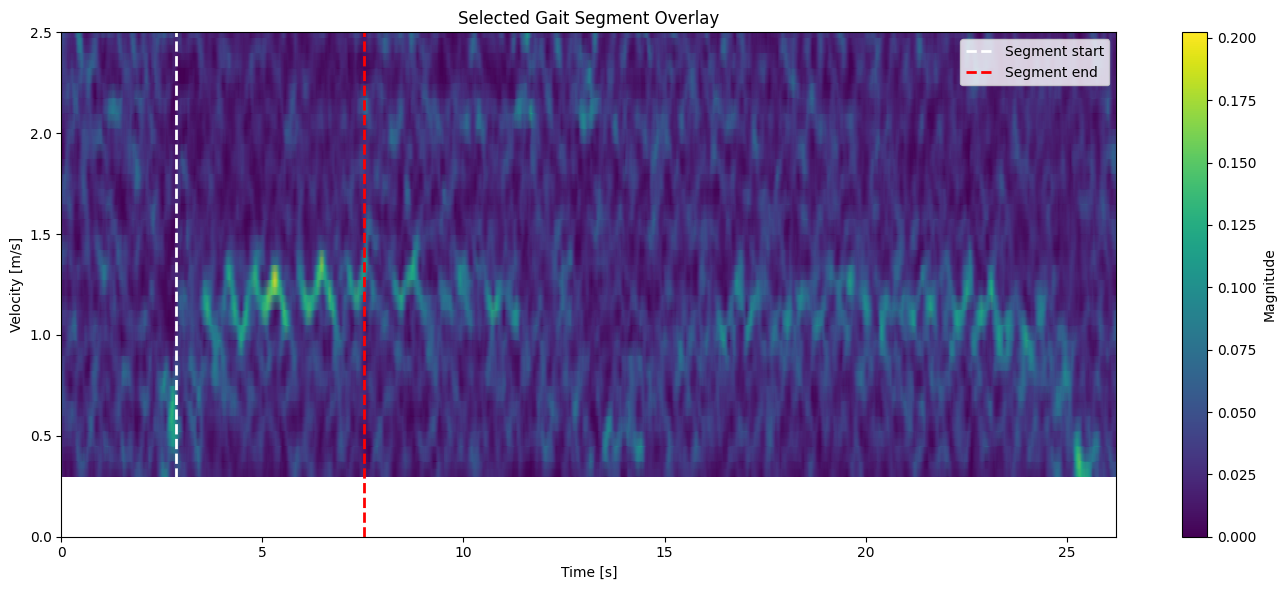


Selected Segment Feature Stats 
Segment start time        : 2.85 s
Segment end time          : 7.52 s
Segment duration          : 4.67 s
Mean torso speed          : 1.214 m/s
Torso speed std           : 0.093 m/s
Mean limb speed           : 2.570 m/s
Limb speed std            : 0.091 m/s
Mean torso contour speed  : 2.620 m/s
Torso contour speed std   : 0.138 m/s
Mean limb/torso ratio     : 2.129
Estimated gait cycle time : 0.920 s


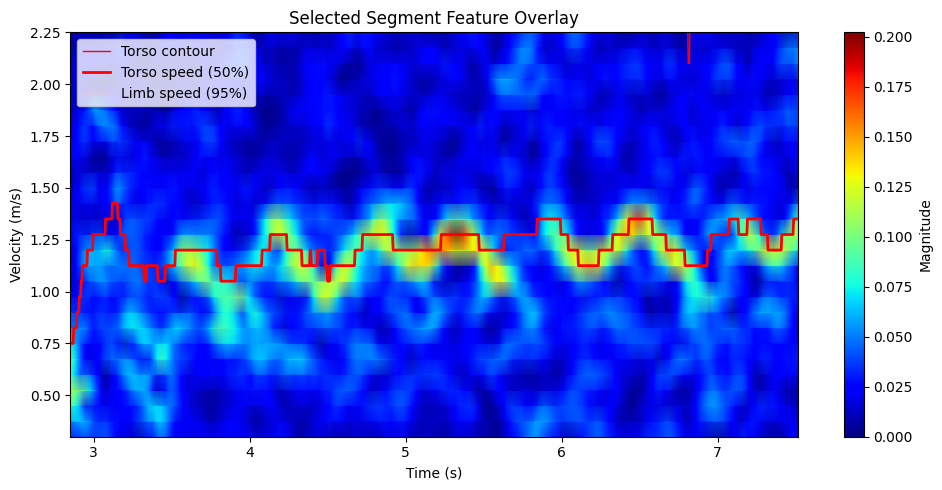

In [48]:
# params to tweak (good for now)
max_torso_std=0.25
max_contour_std=0.30
max_limb_std=0.22


def calculate_movement_speed(S, t, f, percentile=0.5, lambda_val=0.06):
    """
    Estimate movement speed curve from spectrogram using cumulative-energy percentile

    Parameters:
        S : 2D array, shape
            Spectrogram magnitude
        t : 1D array
            Time axis
        f : 1D array
            Frequency axis in Hz
        percentile : float
            0.5 for torso, 0.95 for limb
        lambda_val : float
            Wavelength in meters

    Returns:
        velocity : 1D array, shape (n_time,)
            Estimated speed curve in m/s
    """
    n_freq, n_time = S.shape
    freq_speed = np.zeros(n_time)

    cumulative_energy = np.cumsum(S, axis=0)
    total_energy = cumulative_energy[-1, :] + 1e-12
    P = cumulative_energy / total_energy[np.newaxis, :]

    for t_idx in range(n_time):
        idx = np.where(P[:, t_idx] >= percentile)[0]
        freq_speed[t_idx] = f[idx[0]] if len(idx) > 0 else 0.0

    velocity = freq_speed * lambda_val / 2
    return velocity

def calculate_torso_contour(S, f_band, gamma=0.015):
    """
    Estimate torso contour frequency from spectrogram

    Parameters:
        S : 2D array, shape (n_freq, n_time)
        f_band : 1D array, frequency axis in Hz
        gamma : float
            Threshold on normalized energy ratio

    Returns:
        freq_tc : 1D array, torso contour frequency in Hz
    """
    energy = np.sum(S, axis=0) + 1e-12
    energy_ratio = S / energy[np.newaxis, :]
    freq_tc = np.zeros(S.shape[1])

    for tt in range(S.shape[1]):
        idx = np.where(energy_ratio[:, tt] > gamma)[0]
        freq_tc[tt] = f_band[idx].max() if idx.size > 0 else 0.0

    return freq_tc


def estimate_gait_cycle_time(torso_contour_freq, t, lambda_=0.06):
    """
    Estimate gait cycle time from torso contour frequency track using autocorrelation
    """
    dt = np.mean(np.diff(t))
    fs_feat = 1.0 / dt

    velocity_tc = torso_contour_freq * lambda_ / 2

    b, a = butter(2, 2.0 / (fs_feat / 2))
    velocity_tc = filtfilt(b, a, velocity_tc)

    vtc_max = np.max(velocity_tc)
    steady_index = velocity_tc > 0.8 * vtc_max
    vtc_steady = velocity_tc[steady_index]

    if len(vtc_steady) < 5:
        raise ValueError("Not enough steady-state samples for autocorrelation")

    vtc_centered = vtc_steady - np.mean(vtc_steady)

    autocorrelation = np.correlate(vtc_centered, vtc_centered, mode='full')
    lags = np.arange(-len(vtc_centered) + 1, len(vtc_centered))
    autocorrelation = autocorrelation[lags >= 0]
    lags = lags[lags >= 0]
    tau = lags / fs_feat

    peaks, _ = find_peaks(autocorrelation, distance=fs_feat * 0.3)

    if len(peaks) == 0:
        raise ValueError("No autocorrelation peaks found")

    tau_half = tau[peaks[0]]
    gait_cycle_time = tau_half #formerly 2 * tau_half but was getting too large cycle time

    return gait_cycle_time

def compute_band_energy_curve(S, f, v_min=0.75, v_max=1.25, lambda_val=0.06):
    """
    Sum spectrogram energy over a velocity band to get energy curve vs time
    """
    v = f * lambda_val / 2
    mask = (v >= v_min) & (v <= v_max)

    if not np.any(mask):
        raise ValueError("Velocity band is empty")

    return np.sum(S[mask, :], axis=0)


def normalized_autocorr_peak(x):
    """
    Periodicity score from normalized autocorrelation
    """
    x = np.asarray(x, dtype=float)

    if len(x) < 8:
        return 0.0

    x = x - np.mean(x)
    sx = np.std(x)
    if sx < 1e-12:
        return 0.0

    ac = np.correlate(x, x, mode='full')
    ac = ac[len(ac)//2:]

    if ac[0] <= 1e-12:
        return 0.0

    ac = ac / ac[0]

    # Ignore lag 0
    peaks, _ = find_peaks(ac[1:], distance=max(1, len(x)//8))
    if len(peaks) == 0:
        return 0.0

    peak_vals = ac[1:][peaks]
    return float(np.max(peak_vals)) if len(peak_vals) > 0 else 0.0


def compute_spectral_variance(f, S, f_min=30.0, f_max=60.0):
    """
    Compute spectral variance over a selected frequency band
    """
    if S.ndim != 2:
        raise ValueError(f"S must be 2D. Got shape {S.shape}")

    freq_mask = (f >= f_min) & (f <= f_max)
    f_band = f[freq_mask]
    S_band = np.maximum(S[freq_mask, :], 0.0)

    energy_t = np.sum(S_band, axis=0) + 1e-12
    P = S_band / energy_t[np.newaxis, :]

    mu_f = np.sum(f_band[:, np.newaxis] * P, axis=0)
    second_moment = np.sum((f_band[:, np.newaxis] ** 2) * P, axis=0)

    V = second_moment - mu_f ** 2
    return np.maximum(V, 0.0)


def plot_spectrogram_overlay(S, t, f, freq_tc=None, torso_speed=None, limb_speed=None,
                             title="Feature Extraction Overlay"):
    """
    Plot spectrogram in velocity coordinates with overlays
    """
    lambda_val = 0.06
    v = f * lambda_val / 2

    plt.figure(figsize=(10, 5))
    plt.pcolormesh(t, v, S, shading='gouraud', cmap='jet')
    plt.colorbar(label='Magnitude')
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.ylim([0.3, 2.25])
    plt.title(title)

    if freq_tc is not None:
        plt.plot(t, freq_tc, color='red', linewidth=1, label="Torso contour")
    if torso_speed is not None:
        plt.plot(t, torso_speed, color='red', linewidth=2, label="Torso speed (50%)")
    if limb_speed is not None:
        plt.plot(t, limb_speed, color='pink', linewidth=1, label="Limb speed (95%)")

    plt.legend()
    plt.tight_layout()
    plt.show()


# Actual segmentation function

def find_final_gait_segment(
    S,
    t,
    f,
    Tmin=3.0,
    v_min=0.75,
    v_max=1.25,
    smooth_sigma=2.0,
    energy_percentile_thresh=55,
    expand_frac=0.40,
    periodicity_thresh=0.20,
    min_mean_energy_frac=0.55,
    max_torso_std=0.25,
    max_contour_std=0.30,
    max_limb_std=0.22
):
    """
    Segmentation pipeline:
      1) compute torso-band energy curve
      2) find the best Tmin-second periodic-energy seed
      3) expand around it
      4) accept/reject based on sanity checks
    """
    dt = np.mean(np.diff(t))
    win_len = int(np.ceil(Tmin / dt))
    if win_len < 3:
        raise ValueError("Window length too small")

    E_torso = compute_band_energy_curve(S, f, v_min=v_min, v_max=v_max)
    E_smooth = gaussian_filter1d(E_torso, sigma=smooth_sigma)

    Eth = np.percentile(E_smooth, energy_percentile_thresh)

    best_score = -np.inf
    best_start = None
    best_end = None
    best_periodicity = None
    best_mean_energy = None


    # Find best seed window
    for start in range(0, len(t) - win_len + 1):
        end = start + win_len
        Ew = E_smooth[start:end]

        mean_energy = np.mean(Ew)
        if mean_energy < Eth:
            continue

        periodicity = normalized_autocorr_peak(Ew)
        energy_std = np.std(Ew)

        score = 3.0 * periodicity + 0.5 * mean_energy + 0.25 * energy_std



        if score > best_score:
            best_score = score
            best_start = start
            best_end = end
            best_periodicity = periodicity
            best_mean_energy = mean_energy

    if best_start is None:
        return None, None, np.zeros(len(t), dtype=bool), E_torso, E_smooth

    # Expand around the best seed
    peak_level = np.max(E_smooth[best_start:best_end])
    expand_thresh = expand_frac * peak_level

    left = best_start
    while left > 0 and E_smooth[left - 1] >= expand_thresh:
        left -= 1

    right = best_end - 1
    while right < len(E_smooth) - 1 and E_smooth[right + 1] >= expand_thresh:
        right += 1

    mask_best = np.zeros(len(t), dtype=bool)
    mask_best[left:right + 1] = True

    t_seg = t[mask_best]
    seg_duration = t_seg[-1] - t_seg[0] if len(t_seg) > 1 else 0.0
    seg_mean_energy = np.mean(E_smooth[mask_best])

    global_mean_energy = np.mean(E_smooth) + 1e-12
    relative_mean_energy = seg_mean_energy / global_mean_energy

    # Segment feature sanity checks
    S_seg = S[:, mask_best]
    f_seg = f

    try:
        torso_speed_seg = calculate_movement_speed(S_seg, t_seg, f_seg, percentile=0.5)
        torso_std_seg = float(np.nanstd(torso_speed_seg))
    except Exception:
        torso_speed_seg = None
        torso_std_seg = np.inf

    try:
        limb_speed_seg = calculate_movement_speed(S_seg, t_seg, f_seg, percentile=0.95)
        limb_std_seg = float(np.nanstd(limb_speed_seg))
    except Exception:
        limb_speed_seg = None
        limb_std_seg = np.inf

    try:
        freq_tc_seg = calculate_torso_contour(S_seg, f_seg, gamma=0.015)
        freq_tc_speed_seg = freq_tc_seg * 0.06 / 2
        contour_std_seg = float(np.nanstd(freq_tc_speed_seg))
    except Exception:
        contour_std_seg = np.inf

    # Final acceptance
    accepted = True
    reason = "Accepted"

    if seg_duration < Tmin:
        accepted = False
        reason = f"Rejected: final segment shorter than Tmin ({seg_duration:.2f} s < {Tmin:.2f} s)"
    elif best_periodicity < periodicity_thresh:
        accepted = False
        reason = f"Rejected: best seed periodicity too low ({best_periodicity:.3f} < {periodicity_thresh:.3f})"
    elif relative_mean_energy < min_mean_energy_frac:
        accepted = False
        reason = (
            f"Rejected: final segment energy too weak relative to overall walk "
            f"({relative_mean_energy:.3f} < {min_mean_energy_frac:.3f})"
        )
    elif torso_std_seg > max_torso_std:
        accepted = False
        reason = f"Rejected: torso speed std too high ({torso_std_seg:.3f} > {max_torso_std:.3f})"
    elif contour_std_seg > max_contour_std:
        accepted = False
        reason = f"Rejected: torso contour std too high ({contour_std_seg:.3f} > {max_contour_std:.3f})"
    elif limb_std_seg > max_limb_std:
        accepted = False
        reason = f"Rejected: limb speed std too high ({limb_std_seg:.3f} > {max_limb_std:.3f})"

    if not accepted:
        return None, None, np.zeros(len(t), dtype=bool), E_torso, E_smooth

    return t[left], t[right], mask_best, E_torso, E_smooth


def plot_energy_curve(t, E_torso, E_smooth, t_start_best=None, t_end_best=None):
    plt.figure(figsize=(12, 4))
    plt.plot(t, E_torso, alpha=0.5, label="Torso-band energy")
    plt.plot(t, E_smooth, linewidth=2, label="Smoothed torso-band energy")

    if t_start_best is not None:
        plt.axvline(t_start_best, color='k', linestyle='--', linewidth=2, label='Selected start')
    if t_end_best is not None:
        plt.axvline(t_end_best, color='r', linestyle='--', linewidth=2, label='Selected end')

    plt.xlabel("Time [s]")
    plt.ylabel("Band energy")
    plt.title("Torso-band energy over time")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Constant psi segmentation implementation

S = STFT_data
f = STFT_freq

t_start_best, t_end_best, mask_best_segment, E_torso, E_smooth = find_final_gait_segment(
    S=S,
    t=t,
    f=f,
    Tmin=3.0,
    v_min=0.75,
    v_max=1.25,
    smooth_sigma=2.0,
    energy_percentile_thresh=55,
    expand_frac=0.40,
    periodicity_thresh=0.20,
    min_mean_energy_frac=0.55,
    max_torso_std=0.25,
    max_contour_std=0.30,
    max_limb_std=0.22
)

print("\n Final Segmentation Decision")

if t_start_best is None:
    print("\nNo valid gait segment found")
else:
    print(f"\nSelected segment: {t_start_best:.2f} s to {t_end_best:.2f} s")


# Plot spectrogram overlay
v_axis = f * 0.06 / 2

plt.figure(figsize=(14, 6))
plt.pcolormesh(t, v_axis, S, shading='gouraud', cmap='viridis')
plt.ylim([0, 2.5])
plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Selected Gait Segment Overlay")
plt.colorbar(label="Magnitude")

if t_start_best is not None:
    plt.axvline(t_start_best, color='w', linestyle='--', linewidth=2, label='Segment start')
    plt.axvline(t_end_best, color='r', linestyle='--', linewidth=2, label='Segment end')
    plt.legend()

plt.tight_layout()
plt.show()

# Segment-only feature extraction

if t_start_best is None or not np.any(mask_best_segment):
    print("No valid segment found, so no segment-only stats computed")
else:
    S_seg = S[:, mask_best_segment]
    t_seg = t[mask_best_segment]
    f_seg = f

    torso_speed_seg = calculate_movement_speed(S_seg, t_seg, f_seg, percentile=0.5)
    limb_speed_seg  = calculate_movement_speed(S_seg, t_seg, f_seg, percentile=0.95)
    freq_tc_seg     = calculate_torso_contour(S_seg, f_seg, gamma=0.015)

    segment_duration = t_seg[-1] - t_seg[0] if len(t_seg) > 1 else 0.0

    torso_mean = np.nanmean(torso_speed_seg)
    torso_std  = np.nanstd(torso_speed_seg)

    limb_mean = np.nanmean(limb_speed_seg)
    limb_std  = np.nanstd(limb_speed_seg)

    freq_tc_speed_seg = freq_tc_seg * 0.06 / 2
    contour_mean = np.nanmean(freq_tc_speed_seg)
    contour_std  = np.nanstd(freq_tc_speed_seg)

    ratio_mean = np.nanmean(limb_speed_seg / (torso_speed_seg + 1e-12))

    print("\nSelected Segment Feature Stats ")
    print(f"Segment start time        : {t_seg[0]:.2f} s")
    print(f"Segment end time          : {t_seg[-1]:.2f} s")
    print(f"Segment duration          : {segment_duration:.2f} s")
    print(f"Mean torso speed          : {torso_mean:.3f} m/s")
    print(f"Torso speed std           : {torso_std:.3f} m/s")
    print(f"Mean limb speed           : {limb_mean:.3f} m/s")
    print(f"Limb speed std            : {limb_std:.3f} m/s")
    print(f"Mean torso contour speed  : {contour_mean:.3f} m/s")
    print(f"Torso contour speed std   : {contour_std:.3f} m/s")
    print(f"Mean limb/torso ratio     : {ratio_mean:.3f}")

    try:
        gait_cycle_seg = estimate_gait_cycle_time(freq_tc_seg, t_seg, lambda_=0.06)
        print(f"Estimated gait cycle time : {gait_cycle_seg:.3f} s")
    except Exception as e:
        print(f"Gait cycle estimate failed on selected segment: {e}")

    plot_spectrogram_overlay(
        S_seg, t_seg, f_seg,
        freq_tc=freq_tc_speed_seg,
        torso_speed=torso_speed_seg,
        limb_speed=limb_speed_seg,
        title="Selected Segment Feature Overlay"
    )


Create feature vector and classify (not currently working):

In [31]:

# Feature vector + CSV save/load + classification

import os
import pandas as pd
import seaborn as sns
from scipy.stats import binned_statistic
from sklearn.neighbors import NearestCentroid

def bin_freq_distribution(S, f, n_bins=30, v_min=0.5, v_max=2.5, lambda_val=0.06):
    """
    Bins the mean frequency distribution in velocity space
    """
    v = f * lambda_val / 2
    v_mask = (v >= v_min) & (v <= v_max)

    velocity = v[v_mask]
    freq_dist = np.mean(S, axis=1)[v_mask]

    avg_energy, _, _ = binned_statistic(
        velocity, freq_dist, statistic='mean', bins=n_bins
    )

    return np.nan_to_num(avg_energy, nan=0.0)

def generate_feature_vector(S, t, f):
    """
    S: spectrogram magnitudes during a constant-psi walking segment
    """
    torso_velocity = calculate_movement_speed(S, t, f, percentile=0.5)
    torso_avg = np.mean(torso_velocity)
    torso_range = np.max(torso_velocity) - np.min(torso_velocity)

    # Use torso contour + corrected gait-cycle function
    freq_tc = calculate_torso_contour(S, f, gamma=0.015)
    cycle_time = estimate_gait_cycle_time(freq_tc, t, lambda_=0.06)

    stride_length = torso_avg * cycle_time

    freq_dist = np.mean(S, axis=1)
    freq_dist_variance = np.var(freq_dist)
    freq_dist_max = np.max(freq_dist)
    freq_binned = bin_freq_distribution(S, f)

    feature_vector = [
        torso_avg,
        torso_range,
        cycle_time,
        stride_length,
        freq_dist_variance,
        freq_dist_max
    ]
    feature_vector.extend(freq_binned.tolist())

    print("Feature vector:")
    print(feature_vector)
    return feature_vector

def load_feature_csv(filename):
    """
    Load a feature CSV and repair bad/missing column names if needed.
    """
    df = pd.read_csv(filename)

    expected_cols = (
    ["Label", "torso_avg", "torso_range", "cycle_time", "stride_length",
     "freq_dist_variance", "freq_dist_max"]
    + [f"velocity_bin_{i}" for i in range(30)]
    + ["Data_Name"]
)

    # If teammate CSV has broken unnamed headers but correct number/order of columns
    if df.shape[1] == 38:
        df.columns = expected_cols
        print("Repaired feature CSV column names automatically.")
        return df

    # Minor cleanup for other possible naming inconsistencies
    rename_map = {}
    if "Data Name" in df.columns and "Data_Name" not in df.columns:
        rename_map["Data Name"] = "Data_Name"
    if "torso avg" in df.columns and "torso_avg" not in df.columns:
        rename_map["torso avg"] = "torso_avg"

    if rename_map:
        df = df.rename(columns=rename_map)

    required_base = [
        "Label", "torso_avg", "cycle_time", "torso_range",
        "stride_length", "freq_dist_variance", "freq_dist_max"
    ]

    missing = [c for c in required_base if c not in df.columns]
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}")

    return df

def prepare_training_data(df):
    """
    Extract X_train and y_train from a loaded feature dataframe
    """
    ignore_cols = ["Label", "Data_Name"]
    #isolating the scalar features:
    #feature_cols = ["torso_avg", "torso_range", "cycle_time", "stride_length"]
    feature_cols = [c for c in df.columns if c not in ignore_cols]

    X_train = df[feature_cols].to_numpy(dtype=float)
    y_train = df["Label"].to_numpy()

    return X_train, y_train, feature_cols

def update_feature_file(feature_vector, data_name, filename='training_feature_vectors.csv'):
    label = input("Input name (press Enter to skip saving): ").strip()
    if label == "":
        print("No label entered. Feature vector not saved.")
        return

    row = [label] + list(feature_vector) + [data_name]

    columns = (
        ["Label", "torso_avg", "torso_range", "cycle_time", "stride_length",
         "freq_dist_variance", "freq_dist_max"]
        + [f"velocity_bin_{i}" for i in range(30)]
        + ["Data_Name"]
    )

    df_new = pd.DataFrame([row], columns=columns)

    if os.path.exists(filename):
        existing = pd.read_csv(filename)
        df_all = pd.concat([existing, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(filename, index=False)
    print(f"Feature vector saved for '{label}' to {filename}.")

def classify_feature_vector(training_vectors, training_labels, feature_vector):
    """
    Classify one feature vector using nearest centroid
    """
    training_vectors = np.asarray(training_vectors, dtype=float)
    training_labels = np.asarray(training_labels)
    feature_vector = np.asarray(feature_vector, dtype=float).reshape(1, -1)

    unique_labels = np.unique(training_labels)

    if len(unique_labels) < 2:
        raise ValueError("Need at least 2 classes for classification")

    if np.all(np.ptp(training_vectors, axis=0) == 0):
        raise ValueError("All training features have zero variance")

    clf = NearestCentroid()
    clf.fit(training_vectors, training_labels)
    predicted_person = clf.predict(feature_vector)[0]
    return predicted_person

import numpy as np
from sklearn.preprocessing import StandardScaler

def classify_feature_vector_with_unknown(training_vectors, training_labels, feature_vector, threshold=2.5):
    """
    Classify a feature vector using nearest-centroid logic with an unknown person option

    Parameters
    training_vectors : array-like, shape (n_samples, n_features)
    training_labels : array-like, shape (n_samples,)
    feature_vector : array-like, shape (n_features,)
    threshold : float
        Maximum standardized distance allowed to assign a known label
        otherwise => unknown person

    Returns
    predicted_label : str
    min_dist : float
    distances : dict
        Distance to each class centroid
    """
    X = np.asarray(training_vectors, dtype=float)
    y = np.asarray(training_labels)
    x = np.asarray(feature_vector, dtype=float).reshape(1, -1)

    unique_labels = np.unique(y)
    if len(unique_labels) < 2:
        raise ValueError("Need at least 2 classes create centroids")

    # Standardize using training data only
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    x_scaled = scaler.transform(x)

    # Compute centroid for each label
    centroids = {}
    for label in unique_labels:
        centroids[label] = X_scaled[y == label].mean(axis=0)

    # Compute distance from test point to each centroid
    distances = {}
    for label, centroid in centroids.items():
        dist = np.linalg.norm(x_scaled[0] - centroid)
        distances[label] = dist

    # Find nearest centroid
    predicted_label = min(distances, key=distances.get)
    min_dist = distances[predicted_label]

    if min_dist > threshold:
        return "unknown", min_dist, distances
    else:
        return predicted_label, min_dist, distances

# Choose training file + optional saving + unknown classification

# Change these flags depending on what you want to do
USE_EXISTING_FEATURES_FILE = True
EXISTING_FEATURES_FILE = "/content/features.csv"   # teammate's file
SAVE_NEW_WALK_TO_OWN_FILE = False         # set True if you want to keep building your own file too
OWN_FEATURES_FILE = "training_feature_vectors.csv"

UNKNOWN_THRESHOLD = 2.5   # starting point; tune later

if t_start_best is None or not np.any(mask_best_segment):
    print("No constant-psi segment available, so feature vector/classification was skipped")
else:
    # Build feature vector from the current walk
    feature_vector = generate_feature_vector(S_seg, t_seg, f_seg)

    # Optional: save this new walk to your own running CSV
    if SAVE_NEW_WALK_TO_OWN_FILE:
        update_feature_file(feature_vector, filename, filename=OWN_FEATURES_FILE)

    # Decide which CSV to use for classification
    if USE_EXISTING_FEATURES_FILE:
        training_file = EXISTING_FEATURES_FILE
    else:
        training_file = OWN_FEATURES_FILE

    print(f"\nUsing training file: {training_file}")

    # Load chosen training file
    df = load_feature_csv(training_file)
    df = df[~df["Label"].isin(["Test", "Test2"])].copy()
    print(df.head())
    print(df.columns)

    # Scatter plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df,
        x="torso_avg",
        y="cycle_time",
        hue="Label",
        palette="tab10",
        s=80
    )
    plt.title("Feature Comparison: Torso Avg vs Cycle Time")
    plt.xlabel("Torso Avg Velocity")
    plt.ylabel("Cycle Time")
    plt.legend(title="Person")
    plt.grid(True)
    plt.show()

    # Velocity-bin plots
    velocity_bins = [c for c in df.columns if "velocity_bin" in c]
    labels = df["Label"].unique()
    for i in range(0, len(labels), 2):
        fig, axes = plt.subplots(1, 2, figsize=(12,4))

        # handle case with only one subplot gracefully
        if not isinstance(axes, np.ndarray):
            axes = np.array([axes])

        for j in range(2):
            if i + j >= len(labels) or j >= len(axes):
                break

            label = labels[i + j]
            ax = axes[j]

            subset = df[df["Label"] == label]

            for _, row in subset.iterrows():
                y = row[velocity_bins].values.astype(float)
                x = np.arange(len(y))
                ax.plot(x, y, alpha=0.6)

            ax.set_title(f"Velocity Distribution: {label}")
            ax.set_xlabel("Velocity Bin")
            ax.set_ylabel("Energy")
            ax.grid(True)

        plt.tight_layout()
        plt.show()

    # Prepare training arrays
    X_train, y_train, feature_cols = prepare_training_data(df)

    print("\nTraining label counts:")
    print(df["Label"].value_counts())

    unique_labels = np.unique(y_train)

    if len(unique_labels) < 2:
        print("Classification skipped: need at least 2 different labels in the training CSV.")

    elif np.all(np.ptp(X_train, axis=0) == 0):
        print("Classification skipped: all training features have zero variance.")

    else:
        predicted_person, min_dist, all_distances = classify_feature_vector_with_unknown(
            X_train,
            y_train,
            feature_vector,
            threshold=UNKNOWN_THRESHOLD
        )

        print("\nUnknown-capable classification result:")
        print("Predicted person:", predicted_person)
        print("Nearest centroid distance:", min_dist)
        print("Distances to centroids:")
        print("Predicted person:", predicted_person)
        print("Nearest distance:", min_dist)
        print("All distances:", all_distances)
        for label, dist in all_distances.items():
            print(f"  {label}: {dist:.4f}")

Feature vector:
[np.float64(1.1464222614840989), np.float64(0.975), np.float64(0.6040000000000001), np.float64(0.6924390459363958), np.float64(0.0002920586340097077), np.float64(0.05567017949732735), 0.03971080444553719, 0.03871791344398962, 0.038033134595170444, 0.0417158401473176, 0.05567017949732735, 0.04869161756127558, 0.042230987652175096, 0.0, 0.04516977356179347, 0.043835212151830144, 0.04151592938890097, 0.043929249832261506, 0.028008159763984356, 0.023251623169369327, 0.0, 0.025103452710157965, 0.026262229510691674, 0.025938903606699808, 0.025422813049938767, 0.020280851128916175, 0.020253583779570875, 0.019156300349500482, 0.0, 0.0216507092559602, 0.026167792183315868, 0.018505140408043314, 0.016918370544500766, 0.019818373394617783, 0.016327203141089375, 0.013138848003076782]

Using training file: /content/features.csv


FileNotFoundError: [Errno 2] No such file or directory: '/content/features.csv'

In [53]:
def compute_spectral_variance(f, S, f_min=30.0, f_max=60.0):
    """
    Compute spectral variance over a selected frequency band
    """
    if S.ndim != 2:
        raise ValueError(f"S must be 2D. Got shape {S.shape}")

    freq_mask = (f >= f_min) & (f <= f_max)
    f_band = f[freq_mask]
    S_band = np.maximum(S[freq_mask, :], 0.0)

    energy_t = np.sum(S_band, axis=0) + 1e-12
    P = S_band / energy_t[np.newaxis, :]

    mu_f = np.sum(f_band[:, np.newaxis] * P, axis=0)
    second_moment = np.sum((f_band[:, np.newaxis] ** 2) * P, axis=0)

    V = second_moment - mu_f ** 2
    return np.maximum(V, 0.0)



def detect_fall_event(S, t, f):
    """
    opposite of walking sementation. A fall is
        - not periodic
        - high variance
        - has energy spike
        - followed by a sharp energy collapse

    need to tune threshold values. get more data

    returns a list of times where a fall was detected
    """
    window_size = 20 #about 2 seconds
    periodicity_before_thresh = 0.4
    periodicity_after_thresh  = 0.25

    energy_spike_thresh = 1.8
    variance_spike_thresh = 2.0
    energy_drop_thresh = 0.6
    periodicity_thresh = 0.3

    E = compute_band_energy_curve(S, f, v_min=0.2, v_max=1.5)
    E_smooth = gaussian_filter1d(E, sigma=1.5)
    V = compute_spectral_variance(f, S)

    dE = np.abs(np.diff(E_smooth))
    dV = np.abs(np.diff(V))

    # pad to match length
    dE = np.concatenate([[0], dE])
    dV = np.concatenate([[0], dV])

    dE_thresh = 1.5 * np.mean(dE)
    dV_thresh = 1.5 * np.mean(dV)

    fall = []
    for i in range(10, len(t) - 10):
        Ew = E_smooth[i - window_size:i + window_size]
        periodicity = normalized_autocorr_peak(Ew)

        pre_energy = np.mean(E_smooth[i-10:i])
        post_energy = np.mean(E_smooth[i:i+10])

        # sudden change in energy band curve
        if dE[i] < dE_thresh and dV[i] < dV_thresh:
            continue

        # high variance
        if V[i] < 1.2 * np.mean(V):
            continue

        # periodicity
        if periodicity > periodicity_thresh:
            continue

        # periodicity before (must be walking before)
        E_before = E_smooth[i - 2*window_size : i - window_size]
        p_before = normalized_autocorr_peak(E_before)

        if p_before < periodicity_before_thresh:
            continue

        # periodicity must break after
        E_after = E_smooth[i : i + window_size]
        p_after = normalized_autocorr_peak(E_after)

        if p_after > periodicity_after_thresh:
            continue

        # # --- 3. after event → low motion ---
        # pre_energy = np.mean(E_smooth[i-10:i])
        # post_energy = np.mean(E_smooth[i:i+10])
        # if post_energy > 0.9 * pre_energy:
        #     continue

        fall.append(t[i])

    return fall, E_smooth, V

def group_falls(falls, gap=1.0, min_dur=0.3, max_dur=1.5):
    """Merge nearby detections into one fall event"""
    if not falls:
        return []

    grouped = []
    current = [falls[0]]

    for f in falls[1:]:
        if f - current[-1] < gap:
            current.append(f)
        else:
            grouped.append((current[0], current[-1]))
            current = [f]

    grouped.append((current[0], current[-1]))

    filtered = []
    for fs, fe in grouped:
        dur = fe - fs

        if dur < min_dur:
            continue  # too short → noise

        if dur > max_dur:
            continue  # too long → not a fall

        filtered.append((fs, fe))

    return filtered




Detected fall events:
None


/tmp/ipykernel_9859/1464480026.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


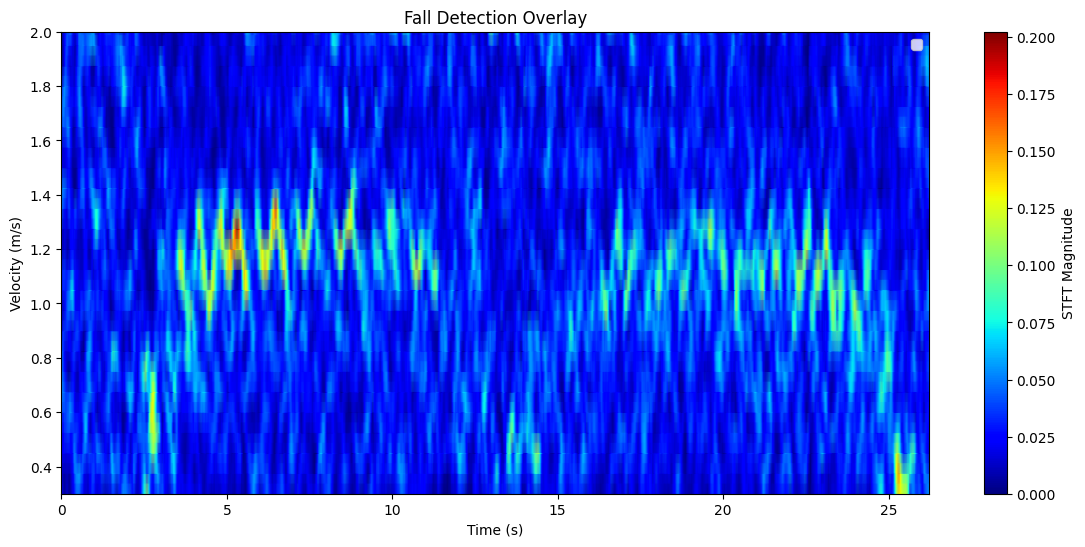

In [54]:
falls, E_smooth, V = detect_fall_event(STFT_data, t, f)
fall_events = group_falls(falls)

print("\nDetected fall events:")
if not fall_events:
    print("None")
else:
    for fs, fe in fall_events:
        print(f"Fall from {fs:.2f}s to {fe:.2f}s")

v_axis = f * 0.06 / 2

plt.figure(figsize=(14,6))
plt.pcolormesh(t, v_axis, STFT_data, shading='gouraud', cmap='jet')
plt.ylim([0, 2.5])

for fs, fe in fall_events:
    plt.axvspan(fs, fe, color='red', alpha=0.3, label='Fall')

plt.title("Fall Detection Overlay")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.ylim([0.3, 2.0])
plt.colorbar(label='STFT Magnitude')
plt.legend()
plt.show()



In [58]:
def plot_combined_detection(
    S, t, f,
    t_start_best=None, t_end_best=None,
    fall_events=None,
    mask_walk=None,
    title="Walking + Fall Detection Overlay"
):
    lambda_val = 0.06
    v_axis = f * lambda_val / 2

    plt.figure(figsize=(14, 6))
    plt.pcolormesh(t, v_axis, S, shading='gouraud', cmap='jet')
    plt.ylim([0.25, 2.5])
    plt.xlabel("Time (s)")
    plt.ylabel("Velocity (m/s)")
    plt.title(title)
    plt.colorbar(label="STFT Magnitude")

    # walking
    if t_start_best is not None:
        plt.axvline(t_start_best, color='white', linestyle='--', linewidth=2, label='Walk start')
        plt.axvline(t_end_best, color='cyan', linestyle='--', linewidth=2, label='Walk end')

    # highlight entire walking region
    if mask_walk is not None and np.any(mask_walk):
        plt.fill_between(
            t, 0, 2.5,
            where=mask_walk,
            color='white',
            alpha=0.15,
            label='Walking region'
        )

    # fall events
    has_fall = False
    if fall_events:
        for i, (fs, fe) in enumerate(fall_events):
            plt.axvspan(
                fs, fe,
                color='red',
                alpha=0.35,
                label='Fall' if i == 0 else None  # avoid duplicate legend entries
            )
    if not has_fall:
        plt.plot([], [], color='red', label='No fall detected')
        plt.text(
            0.02, 0.95,
            "No Fall Detected",
            transform=plt.gca().transAxes,
            fontsize=14,
            color='white',
            verticalalignment='top',
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')
        )
    plt.ylim([0.3,2.0])
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_9859/1356096293.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


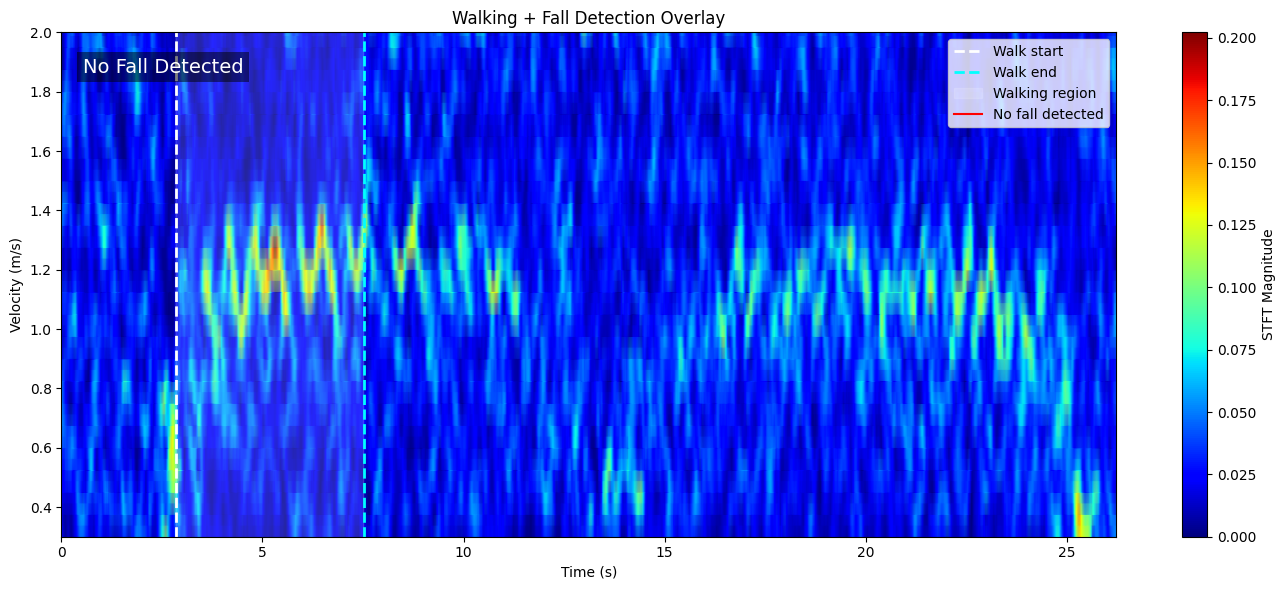

In [59]:
plot_combined_detection(
    S=STFT_data,
    t=t,
    f=f,
    t_start_best=t_start_best,
    t_end_best=t_end_best,
    fall_events=fall_events,
    mask_walk=mask_best_segment
)